In [1]:
#cfbd==4.5.2

In [2]:
import time
start_time = time.time()

In [3]:
#parameters
current_year = None
current_week = None
client_name = None

In [4]:
if not (current_year or current_week or client_name):
    current_year = 2025
    current_week = 14
    client_name = "notebook"

In [5]:
start_year = 2022

current_year_week = f"{current_year}_{current_week}"

In [6]:
#distance travveled latitude and longitude
# https://collegefootballdata.com/glossary

# Imports

In [7]:
import os
if os.environ.get("LOCALHOST") == "True":
    os.chdir('/Users/willboyd/Desktop/Repos/sports-models')

environment = os.environ.get("ENVIRONMENT")

In [8]:
from __future__ import print_function
import os
import numpy as np
import cfbd
from pprint import pprint
import pandas as pd
import datetime

import matplotlib.pyplot as plt

plt.style.use('fivethirtyeight')
plt.rcParams["figure.figsize"] = [20,10]

In [9]:
from pathlib import Path

DATA_DIR = "src/sports/football/cfb/starter_pack_data"

import numpy as np

def safe_bool(val):
    if pd.isna(val):
        return np.nan
    val_str = str(val).strip().lower()
    return val_str in ['true', '1', 'yes']

games_csv = pd.read_csv(
    f"{DATA_DIR}/games.csv", 
    converters={
        'start_time_tbd': safe_bool,
        'conference_game': safe_bool,
        'notes': str
    })
games_csv = games_csv[games_csv['season'] >= start_year].copy()
games_csv = games_csv[games_csv['season'] < 2024].copy()


advanced_game_stats_csv = pd.DataFrame()
for year in range(start_year-1, 2024): #up to 2024

    for file in Path(f"{DATA_DIR}/advanced_game_stats").glob(f"{year}*.csv"):
        temp_df = pd.read_csv(file)
        advanced_game_stats_csv = pd.concat([advanced_game_stats_csv, temp_df], ignore_index=True)


In [10]:
import re

configuration = cfbd.Configuration(
    access_token = os.environ["CFBD_API_KEY"]
)

games_api_df = pd.DataFrame()
advanced_game_stats_api_df = pd.DataFrame()

lines_api_df = pd.DataFrame()
epa_by_game_api_df = pd.DataFrame()

def camel_to_snake(name):
    s1 = re.sub('(.)([A-Z][a-z]+)', r'\1_\2', name)
    s2 = re.sub('([a-z0-9])([A-Z])', r'\1_\2', s1)
    return s2.lower()



with cfbd.ApiClient(configuration) as api_client:
    betting_api = cfbd.BettingApi(api_client)
    game_api = cfbd.GamesApi(api_client)
    metrics_api = cfbd.MetricsApi(api_client)
    adjusted_metrics_api = cfbd.AdjustedMetricsApi(api_client)
    stats_api = cfbd.StatsApi(api_client)

    # year = 2024 # int | Optional year filter (optional)
    # team = 'Texas' # str | Optional team filter (optional)
    # conference = 'SEC' # str | Optional conference abbreviation filter (optional)
    # position = 'QB' # str | Optional position abbreviation filter (optional)
    season_type = 'regular'

    for year in range(start_year-1 , current_year+1):
        temp_lines = pd.DataFrame([element.to_dict() for element in betting_api.get_lines(year=year, season_type = season_type)])
        temp_lines.columns = [camel_to_snake(col) for col in temp_lines.columns]
        lines_api_df = pd.concat([lines_api_df, temp_lines])

        if year > games_csv['season'].max():
            temp_games = pd.DataFrame([element.to_dict() for element in game_api.get_games(year=year, season_type = season_type)])
            temp_games.columns = [camel_to_snake(col) for col in temp_games.columns]
            games_api_df = pd.concat([games_api_df, temp_games])

        epa_by_game_temp = pd.DataFrame([element.to_dict() for element in metrics_api.get_predicted_points_added_by_game(year=year, season_type = season_type)])
        epa_by_game_temp.columns = [camel_to_snake(col) for col in epa_by_game_temp.columns]
        epa_by_game_api_df = pd.concat([epa_by_game_api_df, epa_by_game_temp])

        if year > advanced_game_stats_csv['season'].max():
            advanced_game_stats_temp = pd.DataFrame([element.to_dict() for element in stats_api.get_advanced_game_stats(year=year, season_type = season_type)])
            advanced_game_stats_temp.columns = [camel_to_snake(col) for col in advanced_game_stats_temp.columns]
            advanced_game_stats_api_df = pd.concat([advanced_game_stats_api_df, advanced_game_stats_temp])

        print(f"{year} done.")

2021 done.
2022 done.
2023 done.
2024 done.
2025 done.


#### Games cleanup

In [11]:
games_clean = games_api_df.reset_index(drop=True).copy()
games_clean["season_type"] = games_clean["season_type"].apply(lambda x: x.value if hasattr(x, "value") else x)
games_clean["home_classification"] = games_clean["home_classification"].apply(lambda x: x.value if hasattr(x, "value") else x)
games_clean["away_classification"] = games_clean["away_classification"].apply(lambda x: x.value if hasattr(x, "value") else x)
games_clean = games_clean.drop(['highlights', 'venue'], axis=1)

In [12]:
game_rename_map = {
    "status": "completed",
    "excitement": "excitement_index",
    "home_team_id": "home_id",
    "away_team_id": "away_id",
    "home_postgame_win_prob": "home_postgame_win_probability",
    "away_postgame_win_prob": "away_postgame_win_probability",
    "home_start_elo": "home_pregame_elo",
    "home_end_elo":   "home_postgame_elo",
    "away_start_elo": "away_pregame_elo",
    "away_end_elo":   "away_postgame_elo",
}

games_csv_clean = games_csv.reset_index(drop=True).copy()
games_csv_clean = games_csv.rename(columns=game_rename_map, errors="ignore")
games_csv_clean["completed"] = games_csv_clean["completed"].eq("completed")
games_csv_clean["start_date"] = (pd.to_datetime(games_csv_clean["start_date"], utc=True, errors="coerce"))
games_csv_clean = games_csv_clean.drop(['away_conference_id', 'home_conference_id'], axis=1)

games_csv_clean = games_csv_clean[list(games_clean.columns)]

In [13]:
games = pd.concat(
    [games_csv_clean, games_clean],      
    ignore_index=True,  
    sort=False          
)

#### Lines cleanup

In [14]:
lines_clean = lines_api_df.reset_index(drop=True).copy()
lines_clean["season_type"] = lines_clean["season_type"].apply(lambda x: x.value if hasattr(x, "value") else x)
lines_clean["home_classification"] = lines_clean["home_classification"].apply(lambda x: x.value if hasattr(x, "value") else x)
lines_clean["away_classification"] = lines_clean["away_classification"].apply(lambda x: x.value if hasattr(x, "value") else x)

lines=lines_clean.copy()

#### EPA cleanup

In [15]:
epa_clean = epa_by_game_api_df.reset_index(drop=True).copy()

epa_clean["season_type"] = epa_clean["season_type"].apply(lambda x: x.value if hasattr(x, "value") else x)

offense_df = epa_clean['offense'].apply(pd.Series)
offense_df.columns = [camel_to_snake(col) for col in offense_df.columns]
offense_df = offense_df.add_prefix('offense_')

defence_df = epa_clean['defense'].apply(pd.Series)
defence_df.columns = [camel_to_snake(col) for col in defence_df.columns]
defence_df = defence_df.add_prefix('defense_')

epa_clean = epa_clean.drop(columns=['offense']).join(offense_df)
epa_clean = epa_clean.drop(columns=['defense']).join(defence_df)

epa = epa_clean.copy()

#### Advanced stats cleanup

In [16]:
advanced_game_stats_clean = advanced_game_stats_api_df.reset_index(drop=True).copy()

offense_df = advanced_game_stats_clean['offense'].apply(pd.Series)
o_passing_plays = offense_df['passingPlays'].apply(pd.Series).add_prefix('passing_plays_')
o_rushing_plays = offense_df['rushingPlays'].apply(pd.Series).add_prefix('rushing_plays_')
o_passing_downs = offense_df['passingDowns'].apply(pd.Series).add_prefix('passing_downs_')
o_standard_downs = offense_df['standardDowns'].apply(pd.Series).add_prefix('standard_downs_')
offense_df = pd.concat(
    [offense_df.drop(columns=['passingPlays', 'rushingPlays', 'passingDowns', 'standardDowns']),
     o_passing_plays, o_rushing_plays, o_passing_downs, o_standard_downs],
    axis=1
)
offense_df.columns = [camel_to_snake(col) for col in offense_df.columns]
offense_df = offense_df.add_prefix('offense_')

defence_df = advanced_game_stats_clean['defense'].apply(pd.Series)
d_passing_plays = defence_df['passingPlays'].apply(pd.Series).add_prefix('passing_plays_')
d_rushing_plays = defence_df['rushingPlays'].apply(pd.Series).add_prefix('rushing_plays_')
d_passing_downs = defence_df['passingDowns'].apply(pd.Series).add_prefix('passing_downs_')
d_standard_downs = defence_df['standardDowns'].apply(pd.Series).add_prefix('standard_downs_')
defence_df = pd.concat(
    [defence_df.drop(columns=['passingPlays', 'rushingPlays', 'passingDowns', 'standardDowns']),
     d_passing_plays, d_rushing_plays, d_passing_downs, d_standard_downs],
    axis=1
)
defence_df.columns = [camel_to_snake(col) for col in defence_df.columns]
defence_df = defence_df.add_prefix('defense_')


advanced_game_stats_clean = advanced_game_stats_clean.drop(columns=['offense']).join(offense_df)
advanced_game_stats_clean = advanced_game_stats_clean.drop(columns=['defense']).join(defence_df)


In [17]:
advanced_game_stats_csv_clean  = advanced_game_stats_csv.reset_index(drop=True).copy()
advanced_game_stats_csv_clean.columns = [camel_to_snake(col) for col in advanced_game_stats_csv_clean.columns]

advanced_game_stats_csv_clean = advanced_game_stats_csv_clean[list(advanced_game_stats_clean.columns)]

In [18]:
advanced_game_stats = pd.concat(
    [advanced_game_stats_csv_clean, advanced_game_stats_clean],      
    ignore_index=True,  
    sort=False          
)

# Games

In [19]:
schedule_cols = ['id', 'season', 'week', 'home_team', 'away_team', 'neutral_site', 'conference_game', 'venue_id', 'start_date', 'home_conference', 'away_conference', 'home_points', 'away_points', 'home_classification', 'away_classification']
schedule = games.copy()[schedule_cols]

schedule['game_id'] = schedule['id']
schedule['timestamp'] = pd.to_datetime(schedule['start_date'])
schedule['weekday'] = schedule['timestamp'].dt.day_name()
schedule['date'] = schedule['timestamp'].dt.date
schedule = schedule.sort_values(by='timestamp') #needed for correct elo calculations

## ELO ratings

In [20]:
def get_elo_win_pct(rating, opp_rating):
    exp = (opp_rating - rating) / 400 #increasing divisor will widen rarting scale
    return 1 / (1 + 10**exp)

def get_new_elos(home_rating, away_rating, margin):
    k = 25 # largest amount elo can change from a single game, higher is more volitile

    home_score = 0.5 # score of 0.5 for a tie
    if margin > 0:
        home_score = 1 # score of 1 for a win
    elif margin < 0:
        home_score = 0 # score of 0 for a loss

    
    expected_home_score = get_elo_win_pct(home_rating, away_rating)
    new_home_score = home_rating + k * (home_score - expected_home_score) 

    away_score = 1 - home_score
    expected_away_score = get_elo_win_pct(away_rating, home_rating)
    new_away_score = away_rating + k * (away_score - expected_away_score)

    return (round(new_home_score), round(new_away_score))

In [21]:
teams = dict()
pregame_home_elos = []
pregame_away_elos = []
postgame_home_elos = []
postgame_away_elos = []

for _, game in schedule.iterrows():
    
    if game['home_team'] in teams:
        home_elo = teams[game['home_team']]
    elif game['home_classification'] == 'fbs':
        home_elo = 1500
    else:
        home_elo = 1200

    if game['away_team'] in teams:
        away_elo = teams[game['away_team']]
    elif game['away_classification'] == 'fbs':
        away_elo = 1500
    else:
        away_elo = 1200

    margin = game['home_points'] - game['away_points']
    new_elos = get_new_elos(home_elo, away_elo, margin)

    pregame_home_elos.append(home_elo)
    pregame_away_elos.append(away_elo)

    postgame_home_elos.append(new_elos[0])
    postgame_away_elos.append(new_elos[1])

    teams[game['home_team']] = new_elos[0]
    teams[game['away_team']] = new_elos[1]

schedule['home_pregame_elo'] = pregame_home_elos
schedule['away_pregame_elo'] = pregame_away_elos
schedule['home_postgame_elo'] = postgame_home_elos
schedule['away_postgame_elo'] = postgame_away_elos

# Betting

In [22]:
import random

def get_preferred_provider_dict(dict_list):
    preferred_providers = ['DraftKings', 'ESPN Bet', 'Bovada', 'consensus']
    for provider in preferred_providers:
        for d in dict_list:
            if d.get('provider') == provider:
                return d

    return random.choice(dict_list) if dict_list else {}

def get_implied_totals(row):
    home_points = (row["over_under"] / 2) - (row["spread"] / 2)
    away_points = (row["over_under"] / 2) + (row["spread"] / 2)
    return pd.Series([home_points, away_points])

provider_series = lines['lines'].apply(get_preferred_provider_dict)
provider_df = pd.DataFrame(provider_series.tolist())
exploded_lines = lines.join(provider_df).reset_index(drop = True)
exploded_lines.columns = [camel_to_snake(col) for col in exploded_lines.columns]
exploded_lines = exploded_lines[['id', 'lines', 'provider', 'spread', 'spread_open', 'over_under', 'over_under_open', 'home_moneyline', 'away_moneyline']]
exploded_lines[['implied_points_home', 'implied_points_away']] = exploded_lines.apply(get_implied_totals, axis=1)

# Avanced Game Stats

In [23]:
from src.sports.football.transforms.common import get_averaged_game_stats
columns = ['offense_explosiveness', 'defense_explosiveness']

game_stats = get_averaged_game_stats(advanced_game_stats, columns)
game_stats.head()

,game_id,season,week,team,opponent,offense_open_field_yards_total,offense_open_field_yards,offense_second_level_yards_total,offense_second_level_yards,offense_line_yards_total,...,defense_passing_downs_ppa,defense_standard_downs_explosiveness,defense_standard_downs_success_rate,defense_standard_downs_ppa,offense_explosiveness_shifted,offense_explosiveness_ewma,offense_explosiveness_ewma_dynamic_window,defense_explosiveness_shifted,defense_explosiveness_ewma,defense_explosiveness_ewma_dynamic_window
0,401281942,2021,1,Alabama,Miami,38,1.055556,46,1.277778,105,...,0.348887,0.704914,0.428571,-0.166017,NaN,NaN,NaN,NaN,NaN,NaN
1,401281942,2021,1,Miami,Alabama,15,0.555556,22,0.814815,74,...,0.774657,0.985529,0.526316,0.201209,NaN,NaN,NaN,NaN,NaN,NaN
2,401281943,2021,1,Arkansas,Rice,66,1.609756,59,1.439024,149,...,-0.035925,0.827416,0.422222,-0.128285,NaN,NaN,NaN,NaN,NaN,NaN
3,401281943,2021,1,Rice,Arkansas,0,0.000000,9,0.236842,73,...,0.482686,1.057402,0.488889,0.131467,NaN,NaN,NaN,NaN,NaN,NaN
4,401281944,2021,1,Akron,Auburn,3,0.093750,17,0.531250,82,...,1.054806,1.161582,0.740741,0.740543,NaN,NaN,NaN,NaN,NaN,NaN


# Form df

In [24]:
df = schedule.merge(epa.rename(columns={'team': 'home_team'}), on=['home_team', 'game_id', 'season', 'week'], how='left')\
.merge(epa.rename(columns={'team': 'away_team'}), on=['away_team', 'game_id', 'season', 'week'], how='left', suffixes=('_home', '_away'))

df = df.merge(game_stats.rename(columns={'team': 'home_team'}), on=['home_team', 'game_id', 'season', 'week'], how='left')\
.merge(game_stats.rename(columns={'team': 'away_team'}), on=['away_team', 'game_id', 'season', 'week'], how='left', suffixes=('_home', '_away'))

df = df.merge(exploded_lines, on=['id'], how='left')

df['pred_team'] = 'undefined'

/var/folders/5r/c_l3tdxx1bq9_7h90f8zr_2w0000gn/T/ipykernel_36073/1672024014.py:5: FutureWarning: Passing 'suffixes' which cause duplicate columns {'opponent_home'} in the result is deprecated and will raise a MergeError in a future version.
  .merge(game_stats.rename(columns={'team': 'away_team'}), on=['away_team', 'game_id', 'season', 'week'], how='left', suffixes=('_home', '_away'))


In [25]:
df = df.dropna(subset=['home_team', 'provider', 'home_moneyline'])

In [26]:
from src.sports.football.cfb.expected_points.utils import prepare_cfb_expected_points_df

df = df.dropna(subset=['home_team', 'provider', 'home_moneyline'])
df = prepare_cfb_expected_points_df(df)

df

,id,season,week,home_team,away_team,neutral_site,conference_game,venue_id,start_date,home_conference,...,provider,spread_line,spread_open,total_line,over_under_open,moneyline_home,moneyline_away,implied_points_home,implied_points_away,pred_team
1,401405059,2022,1,Northwestern,Nebraska,True,True,3504.0,2022-08-27 16:30:00+00:00,B1G,...,Bovada,13.0,10.0,52.0,52.0,-450.0,335.0,19.50,32.50,undefined
6,401405058,2022,1,Illinois,Wyoming,False,False,3832.0,2022-08-27 20:00:00+00:00,B1G,...,Bovada,-14.0,-9.5,43.0,46.5,-400.0,300.0,28.50,14.50,undefined
10,401426530,2022,1,Florida Atlantic,Charlotte,False,True,3715.0,2022-08-27 23:00:00+00:00,CUSA,...,Bovada,-7.0,-5.5,60.0,57.5,-300.0,250.0,33.50,26.50,undefined
12,401426531,2022,1,UTEP,North Texas,False,True,3946.0,2022-08-28 01:00:00+00:00,CUSA,...,Bovada,1.5,3.0,54.0,57.0,105.0,-125.0,26.25,27.75,undefined
13,401409235,2022,1,New Mexico State,Nevada,False,False,3601.0,2022-08-28 02:00:00+00:00,Ind,...,Bovada,7.5,14.0,48.0,55.5,270.0,-340.0,20.25,27.75,undefined
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14898,401777329,2025,15,Western Michigan,Miami (OH),True,False,3727.0,2025-12-06 17:00:00+00:00,Mid-American,...,DraftKings,-2.5,NaN,44.5,43.5,-142.0,120.0,23.50,21.00,undefined
14916,401777351,2025,15,Alabama,Georgia,True,False,5348.0,2025-12-06 21:00:00+00:00,SEC,...,DraftKings,1.5,NaN,48.5,NaN,105.0,-125.0,23.50,25.00,undefined
14917,401777328,2025,15,Virginia,Duke,True,False,3628.0,2025-12-07 01:00:00+00:00,ACC,...,DraftKings,-3.5,NaN,58.5,NaN,-175.0,145.0,31.00,27.50,undefined
14918,401777353,2025,15,Ohio State,Indiana,True,False,3812.0,2025-12-07 01:00:00+00:00,Big Ten,...,DraftKings,-3.5,NaN,45.5,48.5,-180.0,150.0,24.50,21.00,undefined


In [27]:
df_filtered = df[
    (df["season"] == 2024) &
    (df["home_team"] == "Texas") &
    (df["away_team"] == "Florida")
]
df_filtered

,id,season,week,home_team,away_team,neutral_site,conference_game,venue_id,start_date,home_conference,...,provider,spread_line,spread_open,total_line,over_under_open,moneyline_home,moneyline_away,implied_points_home,implied_points_away,pred_team
10328,401628417,2024,11,Texas,Florida,False,True,3910.0,2024-11-09 17:00:00+00:00,SEC,...,DraftKings,-23.0,-17.5,48.5,NaN,-2800.0,1300.0,35.75,12.75,undefined


# Feature Prep

In [28]:
from src.model_patterns.expected_points.types import ExpectedPointsConfig

targets = ["home_score", "away_score"]
ewma_features = [column for column in df.columns if "ewma" in column and "dynamic" in column]
cat_features = [col for col in ["weekday"] if col in df.columns]

betting_features = [
    col
    for col in ["moneyline_home", "spread_line", "total_line"]
    if col in df.columns
]

other_features = [
    col
    for col in [
        # "rest_away",
        # "rest_home",
        "conference_game",
        "implied_points_home",
        "implied_points_away",
        "home_pregame_elo",
        "away_pregame_elo",
    ]
    if col in df.columns
]

features = other_features + cat_features + ewma_features
input_features = features

spread_class_features = [col for col in (input_features + betting_features )] #+spread_diff
total_class_features = [col for col in (input_features + betting_features )] #+total_diff

spread_class_cat_features = cat_features
total_class_cat_features = cat_features

ep_config = ExpectedPointsConfig(
    current_year=current_year,
    current_week=current_week,
    targets=targets,
    features=features,
    input_features=input_features,
    spread_class_features=spread_class_features,
    total_class_features=total_class_features,
    cat_features=cat_features,
    spread_class_cat_features=spread_class_cat_features,
    total_class_cat_features=total_class_cat_features,
    home_prediction_features=features,
    away_prediction_features=input_features,
    score_n_jobs=1,
    confidence_n_jobs=1,
)


# Train model

In [29]:
from src.model_patterns.expected_points import run_expected_points

ep_run = run_expected_points(df=df, config=ep_config)

train_df = ep_run.train_df.copy()
results = ep_run.eval_results.copy()
this_week = ep_run.this_week.copy()
plays = ep_run.plays.copy()


# Model metrics and performance


In [30]:
current_week

14

Total win percentage: 48.220640569395016
Spread win percentage: 47.32297063903281


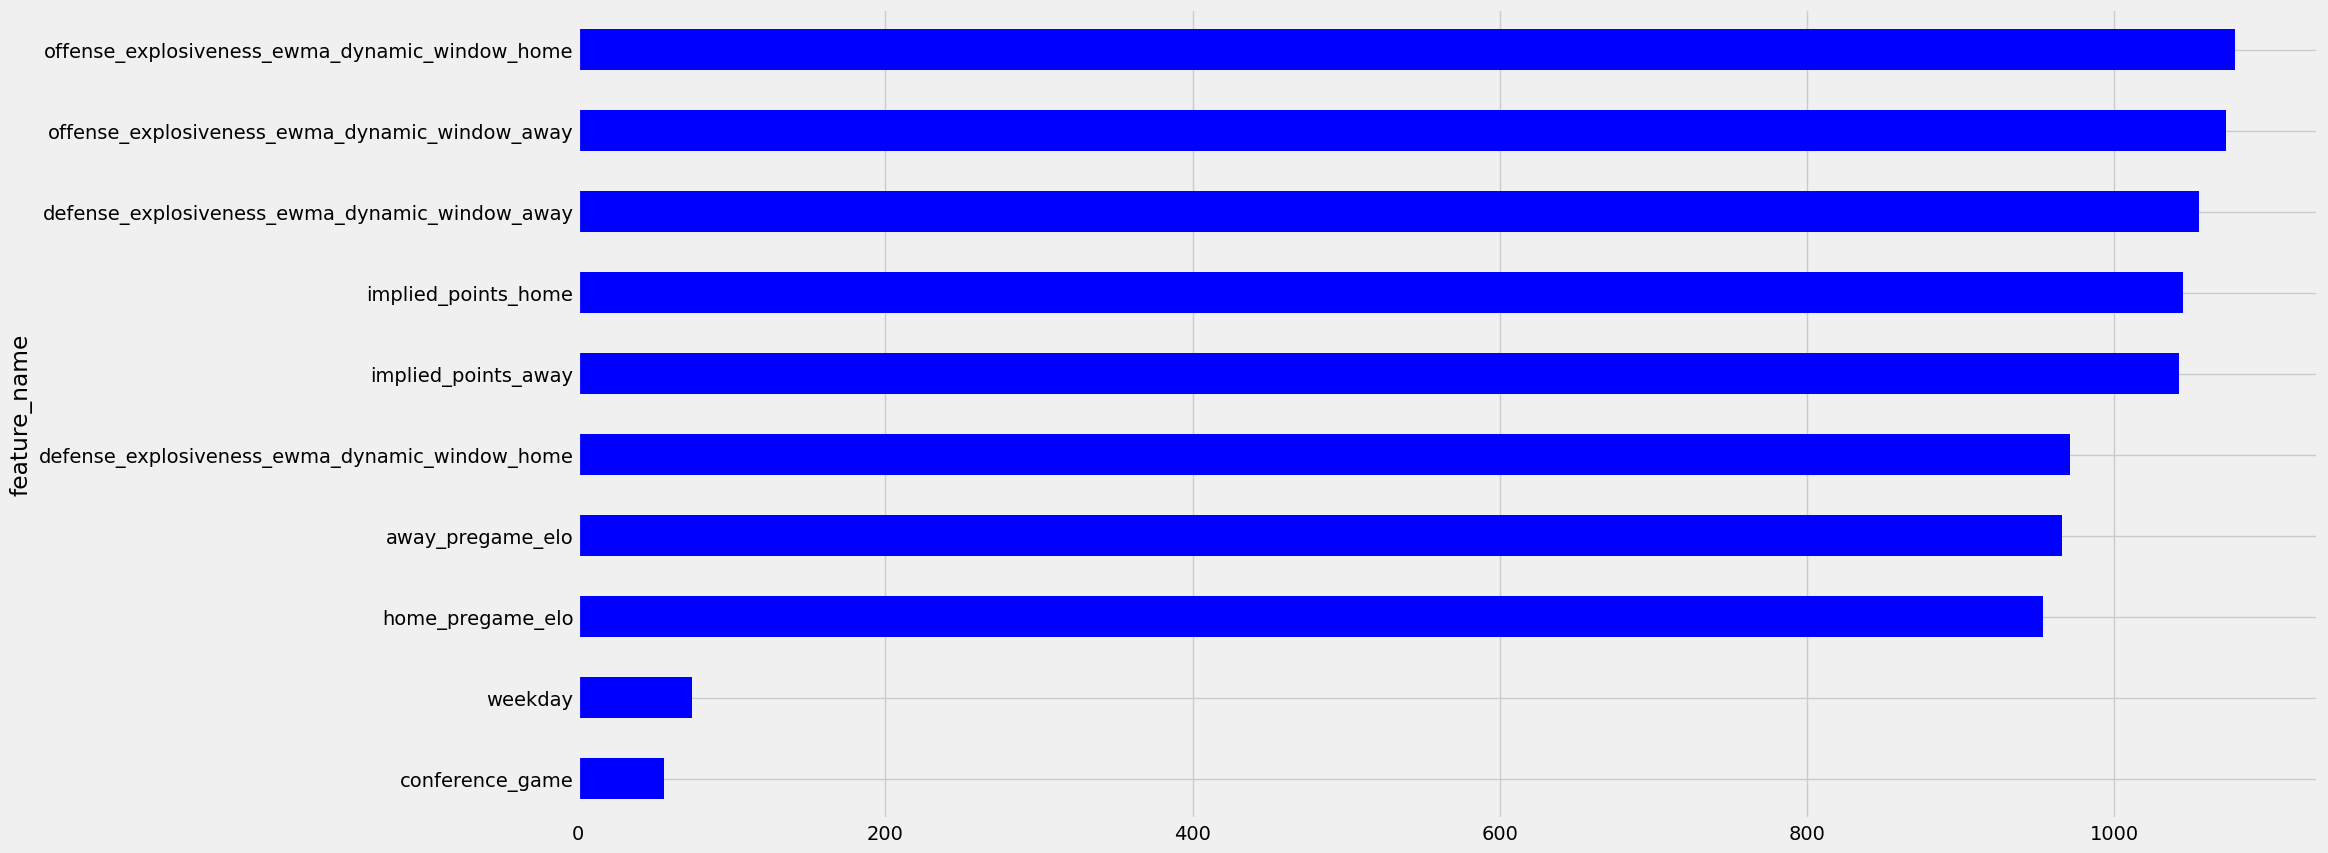

In [31]:
from src.model_patterns.expected_points.reporting import get_feature_importance_df, summarize_eval_results
from matplotlib import pyplot as plt

summary = summarize_eval_results(results)
print(f"Total win percentage: {summary['total_win_pct']}\nSpread win percentage: {summary['spread_win_pct']}")

import_df = get_feature_importance_df(ep_run.score_model, ep_config.features)
if not import_df.empty:
    feature_imp = import_df.set_index('feature_name')['feature_importance']
    feature_imp.plot(kind='barh', color='blue')
    plt.show()


In [32]:
from scipy.stats import pointbiserialr

for col in ['moneyline_home', 'spread_diff']:
    if col in results.columns:
        mask = results['spread_win'].notna() & results[col].notna()
        if mask.sum() > 2:
            corr, _ = pointbiserialr(results.loc[mask, 'spread_win'], results.loc[mask, col])
            print(f"Pearsons correlation ({col}): {corr:.3f}")


Pearsons correlation (moneyline_home): 0.074
Pearsons correlation (spread_diff): 0.015


# This week's plays


In [33]:
from src.model_patterns.expected_points.reporting import print_plays

print_plays(plays)
plays[['season', 'week', 'home_team', 'away_team', 'home_score_pred', 'away_score_pred',
      'spread_pred', 'spread_line', 'spread_play', 'spread_win_prob', 'spread_lock',
      'total_pred', 'total_line', 'total_play', 'total_win_prob', 'total_lock']]


Spread plays:
Nevada/UNLV: UNLV -7.5 (model UNLV -8.95, 95.03% win probability)
Washington State/Oregon State: Washington State -14.0 (model Washington State -17.33, 88.29% win probability)
Massachusetts/Bowling Green: Massachusetts +14.0 (model Massachusetts +9.33, 84.38% win probability)

Total plays:
Tulsa/UAB: over 56.5 (model 63.12, 97.61% win probability)
Rutgers/Penn State: under 55.5 (model 54.80, 92.00% win probability)
Marshall/Georgia Southern: under 62.5 (model 59.14, 91.62% win probability)
Delaware/UTEP: over 55.5 (model 57.95, 90.41% win probability)
California/SMU: under 53.5 (model 49.07, 89.96% win probability)


,season,week,home_team,away_team,home_score_pred,away_score_pred,spread_pred,spread_line,spread_play,spread_win_prob,spread_lock,total_pred,total_line,total_play,total_win_prob,total_lock
14794,2025,14,Massachusetts,Bowling Green,19.423938,28.753181,9.329243,14.0,Massachusetts,84.378946,1,48.177119,44.5,over,77.025922,0
14795,2025,14,Eastern Michigan,Western Michigan,18.192844,25.970437,7.777593,10.0,Eastern Michigan,21.770809,0,44.163281,49.5,under,16.845859,0
14797,2025,14,Memphis,Navy,30.818721,29.541228,-1.277493,-4.0,Navy,45.021193,0,60.359949,57.5,over,80.263960,0
14798,2025,14,Buffalo,Ohio,24.014425,27.029089,3.014664,7.0,Buffalo,63.279990,0,51.043514,44.5,over,50.554596,0
14799,2025,14,Kansas,Utah,21.959655,31.008840,9.049185,10.0,Kansas,71.004738,0,52.968495,60.5,under,1.873712,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14883,2025,14,California,SMU,16.078836,32.993783,16.914947,13.5,SMU,55.117382,0,49.072618,53.5,under,89.960923,1
14884,2025,14,Nevada,UNLV,20.492751,29.438676,8.945925,7.5,UNLV,95.033645,1,49.931427,52.5,under,21.667157,0
14885,2025,14,San José State,Fresno State,20.909921,29.608797,8.698876,3.0,Fresno State,55.078552,0,50.518718,45.5,over,83.423648,0
14886,2025,14,Stanford,Notre Dame,6.265431,37.319169,31.053739,32.5,Stanford,20.886602,0,43.584600,49.5,under,74.882884,0
